In [1]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Set up data path - point to the RUT dataset
data_path = "/home/xdevos/Repositories/pyHi-M/traceratops/data/RUT"

# Set up destination folder for output
dest_path = "/home/xdevos/Repositories/pyHi-M/traceratops/data/output"

print(f"Data path: {data_path}")
print(f"Output path: {dest_path}")
print(f"\nAvailable ROIs:")
for d in sorted(Path(data_path).iterdir()):
    if d.is_dir() and "ROI" in d.name:
        print(f"  {d.name}")

Data path: /home/xdevos/Repositories/pyHi-M/traceratops/data/RUT
Output path: /home/xdevos/Repositories/pyHi-M/traceratops/data/output

Available ROIs:
  013_ROI
  014_ROI
  015_ROI
  017_ROI
  018_ROI
  019_ROI
  020_ROI
  021_ROI
  022_ROI
  023_ROI
  024_ROI
  025_ROI
  026_ROI


# Tutorial 1: Merge Multi-ROI Chromatin Trace Data

This tutorial walks through the standard workflow for merging chromatin tracing data from multiple regions of interest (ROIs):

1. **Collect** trace files from all ROIs into one folder
2. **Assess quality** by computing Pearson correlations between ROIs
3. **Remove** ROIs with poor correlation (outliers)
4. **Re-assess** the correlation matrix after removal
5. **Merge** the remaining trace files into a single table
6. **Statistics** on the merged dataset
7. **Next steps** — link to Tutorial 2 for quality control

## Step 1: Collect trace files from all ROIs

`collect_files` scans each subdirectory of `--root` for a file matching `--example-file`.
The `--variable-part "13"` indicates that the ROI number varies; fixed-length matching naturally excludes Matrix files (different filename length).

In [2]:
!collect_files --root {data_path} --example-file "Trace_3D_barcode_mask-mask0_ROI-13.ecsv" --variable-part "13" --copy-to {dest_path}/raw_traces --force

Matched (13):
  013_ROI -> /home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/013_ROI/tracing/data/Trace_3D_barcode_mask-mask0_ROI-13.ecsv
  014_ROI -> /home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/014_ROI/tracing/data/Trace_3D_barcode_mask-mask0_ROI-14.ecsv
  015_ROI -> /home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/015_ROI/tracing/data/Trace_3D_barcode_mask-mask0_ROI-15.ecsv
  017_ROI -> /home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/017_ROI/tracing/data/Trace_3D_barcode_mask-mask0_ROI-17.ecsv
  018_ROI -> /home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/018_ROI/tracing/data/Trace_3D_barcode_mask-mask0_ROI-18.ecsv
  019_ROI -> /home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/019_ROI/tracing/data/Trace_3D_barcode_mask-mask0_ROI-19.ecsv
  020_ROI -> /home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/020_ROI/tracing/data/Trace_3D_barcode_mask-mask0_ROI-20.ecsv
  021_ROI -> /home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/021_ROI/tracing/data/Tr

## Step 2: Compute Pearson correlations between ROIs

`trace_pearsons` computes a pairwise distance map for each ROI (median 3D distance between every barcode pair), then calculates the Pearson correlation between these maps.

A high correlation between two ROIs means they share similar chromatin organization. An ROI with low correlation against all others is likely an outlier (imaging artifact, poor segmentation, etc.).

Analyzing 13 trace files...
Processing Trace_3D_barcode_mask-mask0_ROI-13.ecsv
$ Importing table from pyHiM format


Successfully loaded trace table: /home/xdevos/Repositories/pyHi-M/traceratops/data/output/raw_traces/Trace_3D_barcode_mask-mask0_ROI-13.ecsv


Processing Trace_3D_barcode_mask-mask0_ROI-14.ecsv
$ Importing table from pyHiM format


Successfully loaded trace table: /home/xdevos/Repositories/pyHi-M/traceratops/data/output/raw_traces/Trace_3D_barcode_mask-mask0_ROI-14.ecsv


Processing Trace_3D_barcode_mask-mask0_ROI-15.ecsv
$ Importing table from pyHiM format


...

Successfully loaded trace table: /home/xdevos/Repositories/pyHi-M/traceratops/data/output/raw_traces/Trace_3D_barcode_mask-mask0_ROI-25.ecsv


Processing Trace_3D_barcode_mask-mask0_ROI-26.ecsv
$ Importing table from pyHiM format


Successfully loaded trace table: /home/xdevos/Repositories/pyHi-M/traceratops/data/output/raw_traces/Trace_3D_barcode_mask-mask0_ROI-26.ecsv



Pearson Correlation Matrix:
[[1.         0.93956888 0.81502328 0.91828281 0.87814176 0.84470165
  0.84801626 0.78200299 0.73928229 0.76365298 0.73501206 0.92867565
  0.92701793]
 [0.93956888 1.         0.83685398 0.95070779 0.88706666 0.88327765
  0.85588491 0.76984358 0.7382629  0.77151501 0.69918238 0.95784962
  0.92697269]
 [0.81502328 0.83685398 1.         0.86827064 0.80359273 0.82257714
  0.78935802 0.74453318 0.68985508 0.67463657 0.69426637 0.84630255
  0.84349145]
 [0.91828287 0.95070779 0.86827064 1.         0.87793595 0.90392911
  0.84807062 0.78833711 0.75207675 0.76865602 0.73396223 0.95285165
  0.9314127 ]
 [0.87814176 0.88706666 0.80359273 0.87793595 1.         0.83209258
  0.79268217 0.79526031 0.7101368  0.72627443 0.69199071 0.88022602
  0.88357335]
 [0.84470165 0.88327771 0.82257714 0.90392923 0.83209258 0.99999988
  0.79047477 0.72918606 0.69684334 0.71265709 0.68656199 0.88801545
  0.87359214]
 [0.84801626 0.85588491 0.78935802 0.84807062 0.79268223 0.79047489
  1

$ Saved correlation matrix as /home/xdevos/Repositories/pyHi-M/traceratops/data/output/trace_correlation_matrix.png
$ Saved correlation matrix data in NPY format: /home/xdevos/Repositories/pyHi-M/traceratops/data/output/trace_correlation_matrix.npy


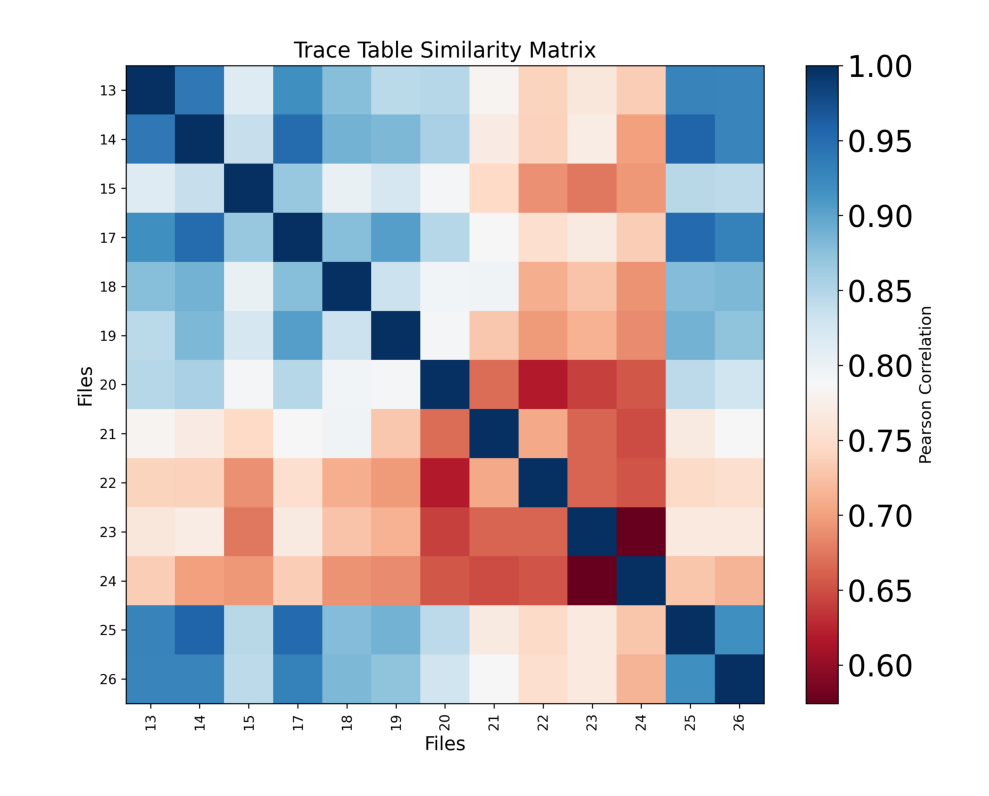

In [3]:
!ls {dest_path}/raw_traces/*.ecsv | trace_pearsons --pipe -O {dest_path}

# Display the correlation matrix
img = mpimg.imread(f"{dest_path}/trace_correlation_matrix.png")
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(img)
ax.axis('off')
plt.tight_layout()
plt.show()

## Step 3: Remove poorly-correlated ROIs

For each ROI, we compute its **mean Pearson correlation** with all other ROIs. ROIs below the threshold are removed from the working folder before merging.

A threshold of **0.70** is conservative: it removes only clear outliers while preserving the vast majority of the data.

In [4]:
# Load the correlation matrix saved by trace_pearsons
corr = np.load(f"{dest_path}/trace_correlation_matrix.npy")
traces = sorted(Path(f"{dest_path}/raw_traces").glob("*.ecsv"))

# Mean correlation per ROI (exclude self-correlation on the diagonal)
np.fill_diagonal(corr, np.nan)
mean_corr = np.nanmean(corr, axis=1)

# Remove ROIs below threshold
threshold = 0.70
for trace, mc in zip(traces, mean_corr):
    if mc < threshold:
        trace.unlink()
        print(f"Removed {trace.name}  (mean Pearson = {mc:.3f})")
    else:
        print(f"Kept    {trace.name}  (mean Pearson = {mc:.3f})")

Kept    Trace_3D_barcode_mask-mask0_ROI-13.ecsv  (mean Pearson = 0.843)
Kept    Trace_3D_barcode_mask-mask0_ROI-14.ecsv  (mean Pearson = 0.851)
Kept    Trace_3D_barcode_mask-mask0_ROI-15.ecsv  (mean Pearson = 0.786)
Kept    Trace_3D_barcode_mask-mask0_ROI-17.ecsv  (mean Pearson = 0.858)
Kept    Trace_3D_barcode_mask-mask0_ROI-18.ecsv  (mean Pearson = 0.813)
Kept    Trace_3D_barcode_mask-mask0_ROI-19.ecsv  (mean Pearson = 0.805)
Kept    Trace_3D_barcode_mask-mask0_ROI-20.ecsv  (mean Pearson = 0.765)
Kept    Trace_3D_barcode_mask-mask0_ROI-21.ecsv  (mean Pearson = 0.738)
Kept    Trace_3D_barcode_mask-mask0_ROI-22.ecsv  (mean Pearson = 0.706)
Kept    Trace_3D_barcode_mask-mask0_ROI-23.ecsv  (mean Pearson = 0.708)
Removed Trace_3D_barcode_mask-mask0_ROI-24.ecsv  (mean Pearson = 0.685)
Kept    Trace_3D_barcode_mask-mask0_ROI-25.ecsv  (mean Pearson = 0.852)
Kept    Trace_3D_barcode_mask-mask0_ROI-26.ecsv  (mean Pearson = 0.846)


## Step 4: Re-run Pearson to verify improvement

After removing the outlier ROIs, the correlation matrix should show higher overall values.

Analyzing 12 trace files...
Processing Trace_3D_barcode_mask-mask0_ROI-13.ecsv
$ Importing table from pyHiM format


Successfully loaded trace table: /home/xdevos/Repositories/pyHi-M/traceratops/data/output/raw_traces/Trace_3D_barcode_mask-mask0_ROI-13.ecsv


Processing Trace_3D_barcode_mask-mask0_ROI-14.ecsv
$ Importing table from pyHiM format


Successfully loaded trace table: /home/xdevos/Repositories/pyHi-M/traceratops/data/output/raw_traces/Trace_3D_barcode_mask-mask0_ROI-14.ecsv


Processing Trace_3D_barcode_mask-mask0_ROI-15.ecsv
$ Importing table from pyHiM format


...

Successfully loaded trace table: /home/xdevos/Repositories/pyHi-M/traceratops/data/output/raw_traces/Trace_3D_barcode_mask-mask0_ROI-25.ecsv


Processing Trace_3D_barcode_mask-mask0_ROI-26.ecsv
$ Importing table from pyHiM format


Successfully loaded trace table: /home/xdevos/Repositories/pyHi-M/traceratops/data/output/raw_traces/Trace_3D_barcode_mask-mask0_ROI-26.ecsv



Pearson Correlation Matrix:
[[1.         0.93956888 0.81502328 0.91828281 0.87814176 0.84470165
  0.84801626 0.78200299 0.73928229 0.76365298 0.92867565 0.92701793]
 [0.93956888 1.         0.83685398 0.95070779 0.88706666 0.88327765
  0.85588491 0.76984358 0.7382629  0.77151501 0.95784962 0.92697269]
 [0.81502328 0.83685398 1.         0.86827064 0.80359273 0.82257714
  0.78935802 0.74453318 0.68985508 0.67463657 0.84630255 0.84349145]
 [0.91828287 0.95070779 0.86827064 1.         0.87793595 0.90392911
  0.84807062 0.78833711 0.75207675 0.76865602 0.95285165 0.9314127 ]
 [0.87814176 0.88706666 0.80359273 0.87793595 1.         0.83209258
  0.79268217 0.79526031 0.7101368  0.72627443 0.88022602 0.88357335]
 [0.84470165 0.88327771 0.82257714 0.90392923 0.83209258 0.99999988
  0.79047477 0.72918606 0.69684334 0.71265709 0.88801545 0.87359214]
 [0.84801626 0.85588491 0.78935802 0.84807062 0.79268223 0.79047489
  1.         0.66896039 0.61917193 0.64099634 0.84364206 0.82929778]
 [0.78200299

$ Saved correlation matrix as /home/xdevos/Repositories/pyHi-M/traceratops/data/output/trace_correlation_matrix.png
$ Saved correlation matrix data in NPY format: /home/xdevos/Repositories/pyHi-M/traceratops/data/output/trace_correlation_matrix.npy


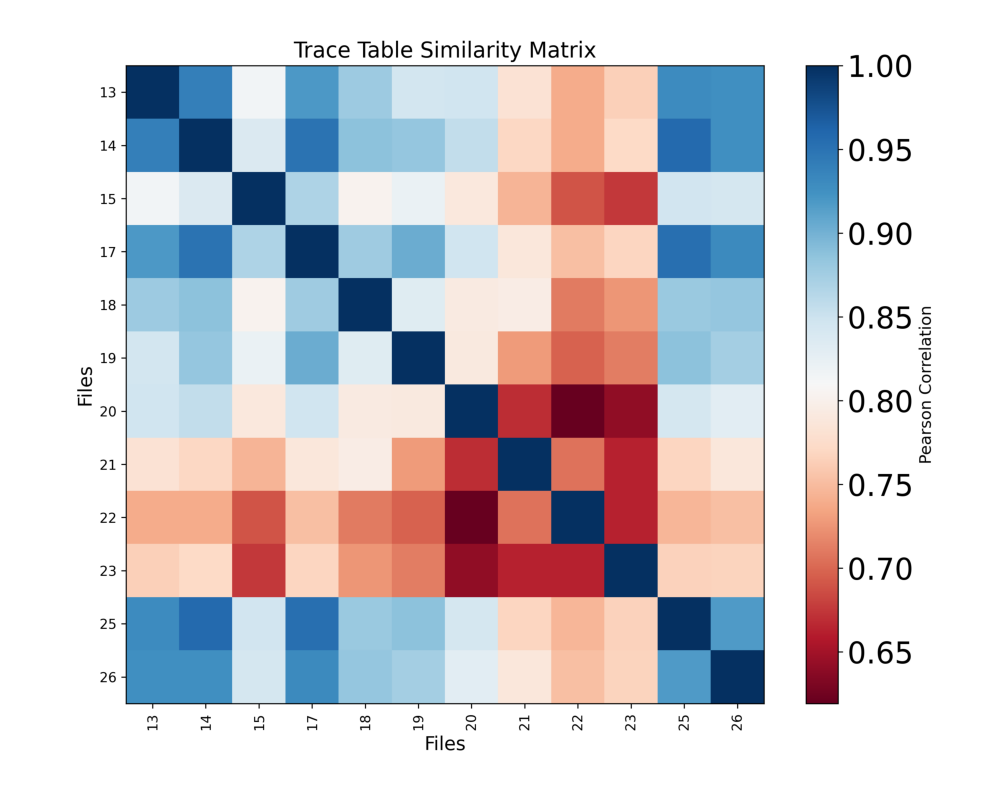

In [5]:
!ls {dest_path}/raw_traces/*.ecsv | trace_pearsons --pipe -O {dest_path}

# Display the updated correlation matrix
img = mpimg.imread(f"{dest_path}/trace_correlation_matrix.png")
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(img)
ax.axis('off')
plt.tight_layout()
plt.show()

## Step 5: Merge trace files

In [6]:
!ls {dest_path}/raw_traces/*.ecsv | trace_merge -F {dest_path} -N merged_traces.ecsv

Number of trace files to merge: 12
$ Importing table from pyHiM format


Successfully loaded trace table: /home/xdevos/Repositories/pyHi-M/traceratops/data/output/raw_traces/Trace_3D_barcode_mask-mask0_ROI-13.ecsv
 $ appended trace file with 13676 traces
$ Importing table from pyHiM format


Successfully loaded trace table: /home/xdevos/Repositories/pyHi-M/traceratops/data/output/raw_traces/Trace_3D_barcode_mask-mask0_ROI-14.ecsv


 $ appended trace file with 13598 traces
$ Importing table from pyHiM format


Successfully loaded trace table: /home/xdevos/Repositories/pyHi-M/traceratops/data/output/raw_traces/Trace_3D_barcode_mask-mask0_ROI-15.ecsv


...

Successfully loaded trace table: /home/xdevos/Repositories/pyHi-M/traceratops/data/output/raw_traces/Trace_3D_barcode_mask-mask0_ROI-25.ecsv


 $ appended trace file with 13684 traces
$ Importing table from pyHiM format


Successfully loaded trace table: /home/xdevos/Repositories/pyHi-M/traceratops/data/output/raw_traces/Trace_3D_barcode_mask-mask0_ROI-26.ecsv


 $ appended trace file with 7313 traces
 $ Merged trace file will contain 115391 traces
Read and accumulated 12 trace files
$ Saving output table as /home/xdevos/Repositories/pyHi-M/traceratops/data/output/merged_traces.ecsv ...


Finished execution


## Step 6: Compute basic statistics

In [7]:
!trace_stats --input {dest_path}/merged_traces.ecsv

$ Importing table from pyHiM format


Successfully loaded trace table: /home/xdevos/Repositories/pyHi-M/traceratops/data/output/merged_traces.ecsv


Statistics for /home/xdevos/Repositories/pyHi-M/traceratops/data/output/merged_traces.ecsv:
- Number of unique ROIs: 12
- Number of unique chromatin traces: 26130
- Number of unique barcodes: 25


## Next steps

The merged trace file is ready for downstream analysis.

Continue with **Tutorial 2 — Quality Control** to:
- Generate detailed quality metrics with `trace_analyzer`
- Interpret barcode detection, neighbor distances, and barcode frequency plots
- Decide on filtering thresholds for Tutorial 3

## Summary

| Step | Script | Output |
|------|--------|--------|
| Collect | `collect_files` | `raw_traces/` (one .ecsv per ROI) |
| Correlations | `trace_pearsons` | `trace_correlation_matrix.png` + `.npy` |
| Filter ROIs | Python (numpy) | removed outlier files from `raw_traces/` |
| Merge | `trace_merge` | `merged_traces.ecsv` |
| Statistics | `trace_stats` | stdout |

**Output location:** `data/output/`